# Memecoin-Season — a quantitative teardown 🔬
### A weekly top-momentum rotation over BTC/DOGE/SHIB · excess-return *t* · a random-rotation placebo · the volatility tax · a persistence-planting control

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Beats_a_coin_flip%3F: Busted](https://img.shields.io/badge/Beats_a_coin_flip%3F-Busted-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). The claim — a mechanical momentum rotation across Bitcoin and the surviving memecoins beats holding Bitcoin, net of costs — is tested as a weekly long-one rotation with a one-week execution lag, benchmarked against BTC HODL and an equal-weight basket.

> ⚠️ **Data note.** BTC/DOGE/SHIB daily close, yfinance, resampled to Friday-close weekly bars. Common window **2021-04-16 → 2026-06-26** (272 weekly bars, 267 rotation weeks; fingerprint `b75635d0b392`). SHIB's sub-1e-10 launch price stores as 0.0 in yfinance, so the tradable universe only begins in April 2021 — a short, mania-dominated sample, said loudly. **Survivorship is named on the Signal axis:** DOGE & SHIB are the two survivors of thousands; every return is an ex-post upper bound. Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md).
>
> 💡 **The `💡 In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"
BLUE = "#2b6cb0"

from memecoin_season import data, strategy as st

HAVE_REAL = data.have_real()
if HAVE_REAL:
    WK = data.weekly_prices()
    DAILY = data.load_prices()
else:
    WK = DAILY = None
print("real cache present:", HAVE_REAL,
      "| weekly bars:", (0 if WK is None else len(WK)))

# frozen headline numbers (mirror of docs/results.md)
R = {'win_lo': '2021-04-16', 'win_hi': '2026-06-26', 'n_weeks': 272, 'n_rot': 267, 'daily_lo': '2021-04-16', 'daily_hi': '2026-06-30', 'daily_n': 1902, 'fp': 'b75635d0b392', 'bh_btc': -5, 'bh_doge': -80, 'bh_shib': 300, 'rot_gross_total': -60, 'rot_gross_sharpe': 0.39, 'rot_gross_dd': -87, 'rot_total': -73.6, 'rot_cagr': -23.0, 'rot_sharpe': 0.34, 'rot_dd': -89, 'rot_vol': 162, 'rot_hit': 42.3, 'n_switches': 68, 'avg_turnover': 0.51, 'btc_total': -2.5, 'btc_cagr': -0.5, 'btc_sharpe': 0.26, 'btc_dd': -74, 'btc_vol': 55, 'ew_total': 217.2, 'ew_cagr': 25.0, 'ew_sharpe': 0.62, 'ew_dd': -80, 'ew_vol': 118, 'excess_mean_wk': 0.717, 'excess_t': 0.59, 'placebo_seeds': 4000, 'placebo_p_total': 0.517, 'placebo_p_sharpe': 0.41, 'rand_median_total': -72, 'rand_median_sharpe': 0.28, 'cost_sweep': {0: (-60, 0.39), 10: (-65, 0.37), 30: (-74, 0.34), 50: (-80, 0.31), 100: (-90, 0.23)}, 'mania_weeks': 33, 'mania_rot_total': 5.1, 'mania_rot_sharpe': 1.01, 'mania_btc_total': -7.2, 'mania_btc_sharpe': 0.18, 'mania_t': 0.83, 'after_weeks': 234, 'after_rot_total': -74.8, 'after_rot_sharpe': 0.08, 'after_btc_total': 29.6, 'after_btc_sharpe': 0.37, 'after_t': -0.32, 'syn_null_mean': 0.06, 'syn_null_sd': 1.15, 'syn_null_fire': 2, 'syn_planted_t': 5.12}


real cache present: True | weekly bars: 272


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | rotation-minus-BTC weekly excess *t* = **0.59** (n=267); random-rotation placebo *p* = **0.52** |
| **Tradability** | `MIRAGE` | net **-74%** vs BTC **-2%** vs equal-weight **+217%**; **-60%** even at zero cost; maxDD **-89%** |
| **Beats a coin flip?** | `BUSTED` | a random weekly coin pick matches/beats it 52% of the time |

> 💡 In plain words: the rotation is dominated by the two things it was supposed to beat (BTC and a naive basket), its signal is indistinguishable from noise, and its one flattering ingredient — owning SHIB — is pure hindsight.

## 1 · The claim, steelmanned

Let the universe be $U = \{\text{BTC}, \text{DOGE}, \text{SHIB}\}$, weekly returns $r_{i,t}$, and the trailing-$L$ momentum $m_{i,t} = P_{i,t}/P_{i,t-L}-1$ known at the close of week $t$. The rotation holds $a_t = \arg\max_i m_{i,t}$ over week $t{+}1$. The claim:

- **H₁ (edge over BTC).** $E[r_{a_t, t+1} - r_{\text{BTC}, t+1}] > 0$, net of costs.
- **H₂ (the signal matters).** the rotation beats a random weekly pick from $U$.

We would call this **Real** only if the weekly excess-over-BTC series clears $|t| \ge 2$ *and* the placebo rejects random allocation. Neither happens.

## 2 · So what? — the survivorship and volatility framing

Two structural facts dominate everything below, so we state them before any number:

1. **Survivorship (Signal axis).** Restricting the memecoin sleeve to DOGE and SHIB — chosen *because* they survived — inflates every buy-and-hold leg. The equal-weight basket's **+217%** is itself an artefact: it is what you'd have made *if you had known in 2021 which two of ten thousand coins to hold*. It is a benchmark the rotation still loses to, not an achievable target.
2. **Volatility tax.** Memecoin weekly vol is enormous. A rotation that ends up **±162%/yr** volatile suffers a geometric-vs-arithmetic gap of order $-\tfrac12\sigma^2$ per period — which is exactly how a strategy can post a *positive* average weekly excess return and still compound to a deep loss.

## 3 · How we'd know — the protocol

- **Tape.** BTC/DOGE/SHIB daily close, yfinance, 1,902 rows 2021-04-16 → 2026-06-30; Friday-close weekly bars, 272 of them 2021-04-16 → 2026-06-26. As-of 2026-06-30 (last complete month; the partial final week is dropped).
- **Signal.** Trailing 4-week return per asset, known at the week's close.
- **Execution.** Hold $\arg\max$ momentum over the **next** week ($\text{choice}.\text{shift}(1)$) — the single documented lag, no look-ahead.
- **Costs.** 30 bps per leg × NAV; a coin-to-coin switch is two legs. Gross and net both reported; a 0→100 bps sweep for break-even.
- **Benchmarks.** BTC HODL and a weekly-rebalanced equal-weight basket, same window.
- **Inference.** Paired weekly excess-over-BTC *t*; a 4,000-seed random-rotation placebo; a pre-2022/post-2022 split.
- **Control.** A 3-asset synthetic world with tunable momentum persistence; the rotation must beat equal-weight only when persistence is planted.

## 4 · The teardown

### 4a · The race — rotation vs BTC vs equal-weight

Growth of 1, net of 30 bps/leg, over the identical window.

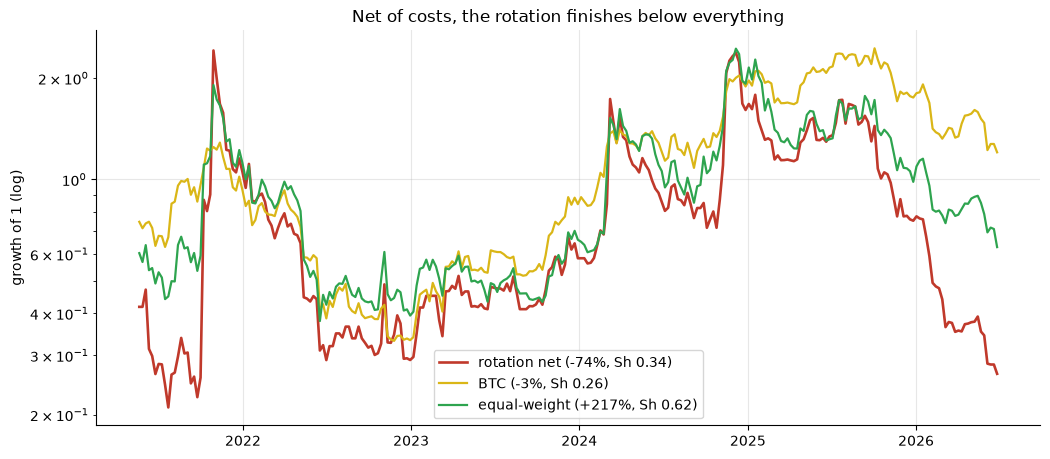

rotation net -73.6% (Sh 0.34, vol 162%, maxDD -89%)
BTC -2.5% (Sh 0.26) | equal-weight +217.2% (Sh 0.62)


In [2]:
if HAVE_REAL:
    net = st.run_rotation(WK, lookback=4, cost_bps=30.0)
    gross = st.run_rotation(WK, lookback=4, cost_bps=0.0)
    btc = st.btc_hodl(WK); ew = st.equal_weight(WK)
    sn = st.summarize(net['net_ret']); sb = st.summarize(btc); se = st.summarize(ew)
    sg = st.summarize(gross['net_ret'])
    idx = net['net_ret'].index
    w_rot = (1+net['net_ret']).cumprod(); w_btc=(1+btc.reindex(idx)).cumprod(); w_ew=(1+ew.reindex(idx)).cumprod()
    fig, ax = plt.subplots(figsize=(10.6, 4.7))
    ax.plot(w_rot.index, w_rot, color=RED, lw=1.9, label=f"rotation net ({sn['total_pct']:+.0f}%, Sh {sn['sharpe']:.2f})")
    ax.plot(w_btc.index, w_btc, color=AMBER, lw=1.6, label=f"BTC ({sb['total_pct']:+.0f}%, Sh {sb['sharpe']:.2f})")
    ax.plot(w_ew.index, w_ew, color=GREEN, lw=1.6, label=f"equal-weight ({se['total_pct']:+.0f}%, Sh {se['sharpe']:.2f})")
    ax.set_yscale('log'); ax.set_ylabel('growth of 1 (log)')
    ax.set_title('Net of costs, the rotation finishes below everything'); ax.legend()
    plt.tight_layout(); plt.show()
    print(f"rotation net {sn['total_pct']:+.1f}% (Sh {sn['sharpe']:.2f}, vol {sn['vol_pct']:.0f}%, maxDD {sn['maxdd_pct']:.0f}%)")
    print(f"BTC {sb['total_pct']:+.1f}% (Sh {sb['sharpe']:.2f}) | equal-weight {se['total_pct']:+.1f}% (Sh {se['sharpe']:.2f})")
else:
    fig, (a1,a2) = plt.subplots(1,2, figsize=(11,4.4))
    a1.bar(['rot','BTC','EW'], [R['rot_total'],R['btc_total'],R['ew_total']], color=[RED,AMBER,GREEN])
    a1.set_ylabel('total %'); a1.set_title('total return')
    a2.bar(['rot','BTC','EW'], [R['rot_sharpe'],R['btc_sharpe'],R['ew_sharpe']], color=[RED,AMBER,GREEN])
    a2.set_ylabel('Sharpe'); a2.set_title('Sharpe'); plt.tight_layout(); plt.show()
    print('rotation net', R['rot_total'], 'BTC', R['btc_total'], 'EW', R['ew_total'])

> 💡 In plain words: the rotation's Sharpe (0.34) is barely above BTC's (0.26) and well below the equal-weight basket's (0.62), while its total return (-74%) is the worst of the three. It gives up return *and* runs the highest volatility (**162%/yr** vs BTC's 55%) — a strictly dominated outcome.

### 4b · Is the edge over BTC real? — and the volatility tax

The paired weekly excess-over-BTC series, and the arithmetic-vs-geometric gap that explains the paradox.

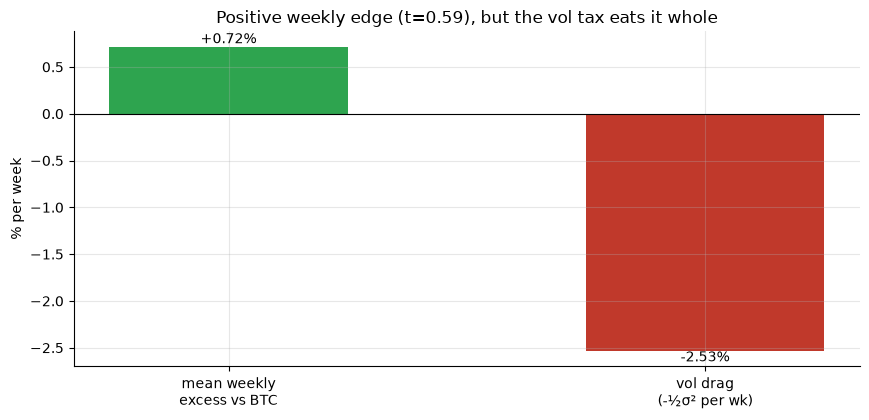

mean weekly excess vs BTC = +0.717%  t = +0.59  (|t|>=2 needed)
weekly vol drag ~ -2.53%/wk — larger than the edge, so it compounds to a loss


In [3]:
if HAVE_REAL:
    ex = st.excess_tstat(net['net_ret'], btc.reindex(net['net_ret'].index))
    mean_wk, tval = ex['mean_excess_pct'], ex['t']
    vol = sn['vol_pct']
else:
    mean_wk, tval, vol = R['excess_mean_wk'], R['excess_t'], R['rot_vol']
sig_w = vol/np.sqrt(52)/100
geo_drag = -0.5*sig_w**2*100
fig, ax = plt.subplots(figsize=(8.8, 4.3))
ax.bar(['mean weekly\nexcess vs BTC','vol drag\n(-½σ² per wk)'], [mean_wk, geo_drag],
       color=[GREEN, RED], width=.5)
for i,v in enumerate([mean_wk, geo_drag]): ax.annotate(f'{v:+.2f}%', (i,v), ha='center', va='bottom' if v>=0 else 'top')
ax.axhline(0, c='k', lw=.8); ax.set_ylabel('% per week')
ax.set_title(f'Positive weekly edge (t={tval:.2f}), but the vol tax eats it whole')
plt.tight_layout(); plt.show()
print(f'mean weekly excess vs BTC = {mean_wk:+.3f}%  t = {tval:+.2f}  (|t|>=2 needed)')
print(f'weekly vol drag ~ {geo_drag:+.2f}%/wk — larger than the edge, so it compounds to a loss')

> 💡 In plain words: the rotation's *average* weekly return actually beats BTC by **0.72%** — but the *t* is only **0.59**, nowhere near the |t| ≥ 2 bar, so even that tiny gap is statistically indistinguishable from zero. And because the strategy is so volatile, the $-\tfrac12\sigma^2$ compounding drag per week is *larger* than the edge — which is precisely how a positive-mean strategy compounds to a catastrophic loss. Volatility isn't just risk here; it's a direct, mechanical cost.

### 4c · The random-rotation placebo — does momentum add anything?

4,000 seeds, each picking a coin uniformly at random every week, same costs and lag. If the momentum rotation can't beat this, the signal is noise.

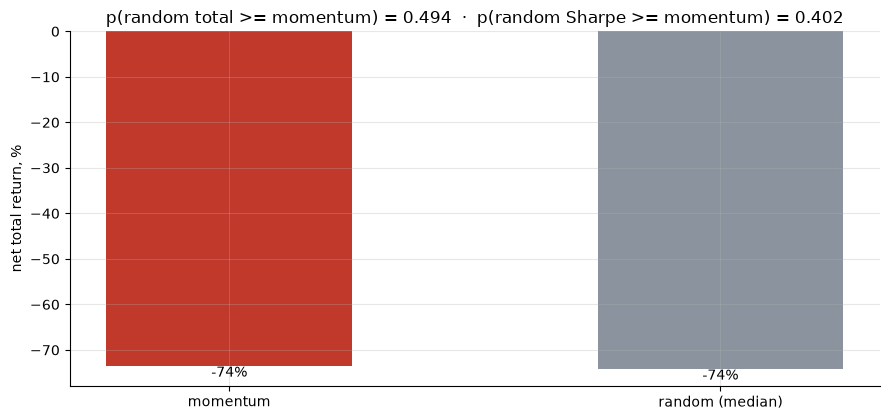

canonical (results.md, 4,000 seeds): p_total = 0.517, p_sharpe = 0.410


In [4]:
if HAVE_REAL:
    pl = st.random_rotation_placebo(WK, cost_bps=30.0, n_seeds=1500)  # lighter in-notebook
    p_tot, p_shp = pl['p_total'], pl['p_sharpe']
    mom_t, rnd_t = pl['mom_total_pct'], pl['rand_total_median_pct']
else:
    p_tot, p_shp = R['placebo_p_total'], R['placebo_p_sharpe']
    mom_t, rnd_t = R['rot_total'], R['rand_median_total']
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.bar(['momentum','random (median)'], [mom_t, rnd_t], color=[RED, GREY], width=.5)
for i,v in enumerate([mom_t, rnd_t]): ax.annotate(f'{v:+.0f}%', (i,v), ha='center', va='top')
ax.set_ylabel('net total return, %')
ax.set_title(f'p(random total >= momentum) = {p_tot:.3f}  ·  p(random Sharpe >= momentum) = {p_shp:.3f}')
plt.tight_layout(); plt.show()
print(f'canonical (results.md, {R["placebo_seeds"]:,} seeds): p_total = {R["placebo_p_total"]:.3f}, p_sharpe = {R["placebo_p_sharpe"]:.3f}')

> 💡 In plain words: a random weekly coin-pick matches or beats the momentum rotation on total return **52%** of the time and on Sharpe **41%** of the time. The momentum ranking is not extracting any exploitable structure — you could replace it with a dice roll and do no worse.

### 4d · Where does any apparent edge live? — the 2021 mania vs after

Split at 2022-01-01. A single euphoric sliver can carry an entire crypto backtest.

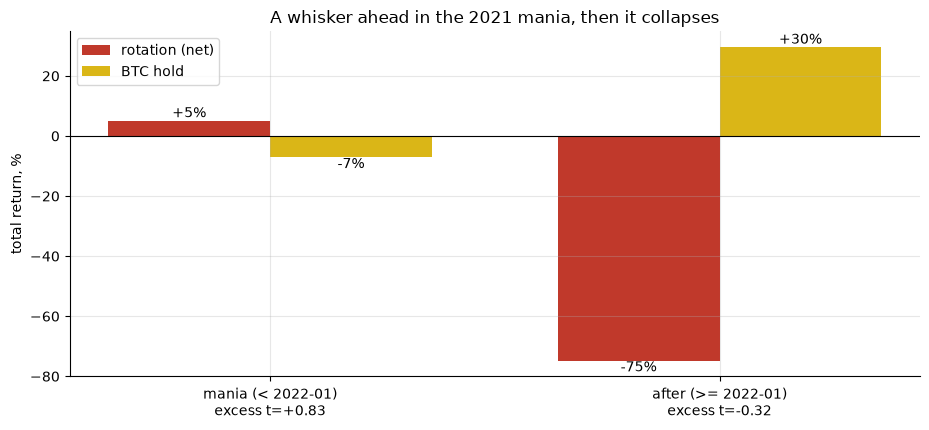

In [5]:
if HAVE_REAL:
    sub = st.subperiod_table(WK, cut='2022-01-01', cost_bps=30.0)
    seg = list(sub.index); rot = list(sub['rot_total_pct']); bt = list(sub['btc_total_pct']); ts = list(sub['excess_t'])
else:
    seg = ['mania (< 2022-01)','after (>= 2022-01)']
    rot = [R['mania_rot_total'], R['after_rot_total']]; bt = [R['mania_btc_total'], R['after_btc_total']]
    ts = [R['mania_t'], R['after_t']]
x = np.arange(len(seg)); w=.36
fig, ax = plt.subplots(figsize=(9.4, 4.4))
ax.bar(x-w/2, rot, width=w, color=RED, label='rotation (net)')
ax.bar(x+w/2, bt, width=w, color=AMBER, label='BTC hold')
for i,v in enumerate(rot): ax.annotate(f'{v:+.0f}%', (x[i]-w/2, v), ha='center', va='bottom' if v>=0 else 'top')
for i,v in enumerate(bt): ax.annotate(f'{v:+.0f}%', (x[i]+w/2, v), ha='center', va='bottom' if v>=0 else 'top')
ax.set_xticks(x); ax.set_xticklabels([f'{s}\nexcess t={t:+.2f}' for s,t in zip(seg,ts)])
ax.set_ylabel('total return, %'); ax.axhline(0,c='k',lw=.8)
ax.set_title('A whisker ahead in the 2021 mania, then it collapses'); ax.legend()
plt.tight_layout(); plt.show()

> 💡 In plain words: in the 2021 mania (33 weeks) the rotation edged BTC (+5% vs -7%) but with *t* = 0.83 — not significant. After 2022 (234 weeks) it lost **75%** while BTC *gained* **+30%** (*t* = -0.32). There is no regime in which the edge is both positive and certified; the flattering half is a tiny, noisy, in-sample window.

### 4e · Faithful-engine & power control — we know the truth here

A 3-asset synthetic weekly world with TUNABLE momentum persistence. Null (persistence = 0, pure random walks) checked over **20 seeds**; a planted-persistence world must be caught.

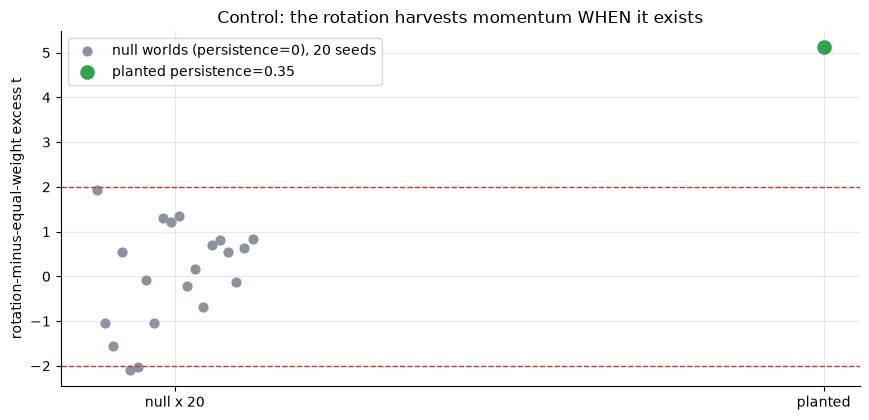

null: mean t = +0.06 (sd 1.15), |t|>=2 in 2/20  |  planted t = +5.12


In [6]:
null_ts = []
for s in range(20):
    w = data.synthetic_world(persistence=0.0, seed=766+s)
    null_ts.append(st.momentum_edge_from_returns(w))
null_ts = np.asarray(null_ts)
w = data.synthetic_world(persistence=0.35, seed=766)
planted_t = st.momentum_edge_from_returns(w)
fig, ax = plt.subplots(figsize=(8.8, 4.3))
ax.scatter(np.zeros(20)+np.linspace(-.12,.12,20), null_ts, color=GREY, s=40, label='null worlds (persistence=0), 20 seeds')
ax.scatter([1],[planted_t], color=GREEN, s=90, zorder=5, label='planted persistence=0.35')
ax.axhline(2, ls='--', c=RED, lw=1); ax.axhline(-2, ls='--', c=RED, lw=1)
ax.set_xticks([0,1]); ax.set_xticklabels(['null x 20','planted'])
ax.set_ylabel('rotation-minus-equal-weight excess t')
ax.set_title('Control: the rotation harvests momentum WHEN it exists'); ax.legend()
plt.tight_layout(); plt.show()
print(f'null: mean t = {null_ts.mean():+.2f} (sd {null_ts.std(ddof=1):.2f}), |t|>=2 in {(abs(null_ts)>=2).sum()}/20  |  planted t = {planted_t:+.2f}')

> 💡 In plain words: when momentum persistence is genuinely present, the rotation detects and harvests it cleanly (*t* = 5.12). On the null it sits at zero (mean *t* = 0.06). So the engine works — which means the real-tape verdict isn't a broken backtest: memecoin weekly returns simply don't carry the exploitable week-to-week momentum the folklore assumes. *(A faithful-engine / power check only — never cited in support of the real-tape stamp.)*

## 5 · The verdict

- **Signal `NONE`** — the weekly excess-over-BTC *t* is **0.59** (n=267), a random-rotation placebo matches/beats the strategy (52% on return, 41% on Sharpe), and no sub-period shows a certified edge. The momentum signal carries no exploitable information on this tape.
- **Tradability `MIRAGE`** — net of a mild 30 bps/leg the rotation returns **-74%** against BTC **-2%** and equal-weight **+217%**, with a **-89%** drawdown and **162%/yr** volatility; it loses **-60%** even at zero cost, so the failure is structural, not fee-driven. And its one flattering leg — owning SHIB — is survivorship (2 winners of thousands).
- **"Beats a coin flip?" `BUSTED`** — a dartboard does as well.

## 6 · Going further

- **The volatility tax is the real lesson.** In ultra-high-vol assets, a strategy with a *positive* average edge can still compound to ruin because $-\tfrac12\sigma^2$ swamps the mean. Any "just ride the momentum" pitch in memecoins runs headlong into this; the fix is sizing (vol-targeting), not signal-picking — and vol-targeting a −t signal buys you nothing.
- **A cash-exit variant** (`cash_option=True` in `run_rotation`) reduces the drawdown but, on this survivorship-flattered tape, still trails BTC — a worthwhile fork to run and report.
- **The honest universe is point-in-time.** Including the thousands of dead memecoins (a proper survivorship-free panel via the desk's opt-in guard) would push every number strictly *worse*; the study already uses the generous survivor universe and the claim still fails.

*The reproducible core is offline and deterministic; frozen numbers live in [`docs/results.md`](../docs/results.md), sources in [`docs/references.md`](../docs/references.md).*